# Intro

Name:  

    NURTURE_HALO_RH_sonde

Purpose:  

    Compare the Tropopause heights derived from drop sondes to the tropopause derived from the RH / H20 Mass mixing Ration

Input:

    none at command line

Output:

    plots

Keywords:

    none

Dependencies:

    - numpy
    - Pyephem
    - pandas

Needed Files:

  - HALO hdf5
  - AVAPS drop sonde netcdf

Modification History:

    Written: Samuel LeBlanc, Goose Bay, Labrador, Canada, 2026-02-12
    Modified: 

# Load the required modules and prepare the paths

In [1]:
import matplotlib 
#matplotlib.rc_file('C:\\Users\\sleblan2\\Research\\python_codes\\file.rc')
import matplotlib.pyplot as plt
#%matplotlib widget
import numpy as np
import os
import scipy.io as sio

In [2]:
import map_utils as mu
import matplotlib.colors as colors
from load_utils import mat2py_time, toutc, load_ict
from path_utils import getpath
from scipy.interpolate import interp1d
from datetime import datetime
from matplotlib.cm import get_cmap

In [3]:
import load_utils as lu
import h5py as hp
import hdf5storage as hs

In [4]:
import pandas as pd
from tqdm.notebook import tqdm

In [12]:
import metpy

In [5]:
fp = getpath('NURTURE2026') #,path=r"/data2/NURTURE/flights_2026",make_path=True)
fp_fl = fp+r'20260207_RF10/'
fp

Return path named:  NURTURE2026 /data2/NURTURE/flights_2026/


'/data2/NURTURE/flights_2026/'

In [6]:
vr = '0'

# load the files

In [7]:
daystr = '20260207'
rf = 'RF10'

## Load the HALO file

In [13]:
halo = hp.File(fp_fl+'NURTURE-HALO_G3_20260207_RA_L1.h5')

In [14]:
halo.keys()

<KeysViewHDF5 ['DataProducts', 'Nav_Data', 'State', 'UserInput', 'time']>

In [15]:
halo['DataProducts'].keys()

<KeysViewHDF5 ['1064_aer_dep', '1064_bsc', '1064_bsc_Sa', '1064_bsc_cloud_screened', '1064_bsr', '1064_bsr_cloud_screened', '1064_dep', '1064_ext', '1064_total_attn_bsc', '532_Sa', '532_aer_dep', '532_bsc', '532_bsc_Sa', '532_bsc_cloud_screened', '532_bsr', '532_bsr_cloud_screened', '532_dep', '532_ext', '532_extinction_from_backscatter', '532_total_attn_bsc', 'Aerosol_ID', 'PWV_bottom_bin_v', 'PWV_clear_v', 'PWV_cloudy_v', 'PWV_top_bin_v', 'RHi_v', 'RHw_v', 'WVD_1064_532', 'cloud_top_height', 'cloud_top_height_935', 'h2o_mmr_v', 'lat', 'lon', 'mask_low', 'range_cell_v', 'z']>

In [16]:
time = halo['time'][:]

In [17]:
z = halo['DataProducts']['z'][:]

In [18]:
lat = halo['Nav_Data']['gps_lat'][:]
lon = halo['Nav_Data']['gps_lon'][:]
alt = halo['Nav_Data']['gps_alt'][:]

In [19]:
len(z),len(alt),len(time)

(831, 1897, 1897)

## Load the AVAPS drop sonde files

In [20]:
files = os.listdir(fp_fl)
AVAPS_files = [f for f in files if 'AVAPS' in f]
AVAPS_files.sort()

In [21]:
sonde = []
sonde_hdr = []
for f in AVAPS_files:
    s,s_dict = lu.load_ict(fp_fl+f,return_header=True)
    sonde.append(s)
    sonde_hdr.append(s_dict)

('Time_Start', 'ElaspedTime', 'Pressure', 'Temperature', 'RH', 'WindSpeed', 'WindDir', 'Latitude', 'Longitude', 'Pressure_Altitude', 'GPS_Altitude', 'Dewpoint', 'U_wind', 'V_wind', 'W_wind', 'DescentRate', 'MixingRatio', 'Theta', 'Theta_e', 'Theta_v', 'T_virtual')
('Time_Start', 'ElaspedTime', 'Pressure', 'Temperature', 'RH', 'WindSpeed', 'WindDir', 'Latitude', 'Longitude', 'Pressure_Altitude', 'GPS_Altitude', 'Dewpoint', 'U_wind', 'V_wind', 'W_wind', 'DescentRate', 'MixingRatio', 'Theta', 'Theta_e', 'Theta_v', 'T_virtual')
('Time_Start', 'ElaspedTime', 'Pressure', 'Temperature', 'RH', 'WindSpeed', 'WindDir', 'Latitude', 'Longitude', 'Pressure_Altitude', 'GPS_Altitude', 'Dewpoint', 'U_wind', 'V_wind', 'W_wind', 'DescentRate', 'MixingRatio', 'Theta', 'Theta_e', 'Theta_v', 'T_virtual')
('Time_Start', 'ElaspedTime', 'Pressure', 'Temperature', 'RH', 'WindSpeed', 'WindDir', 'Latitude', 'Longitude', 'Pressure_Altitude', 'GPS_Altitude', 'Dewpoint', 'U_wind', 'V_wind', 'W_wind', 'DescentRate',

# Plot the inital curtains

In [22]:
lvls = np.flip(1.6-np.log(np.arange(1,5,0.1)))

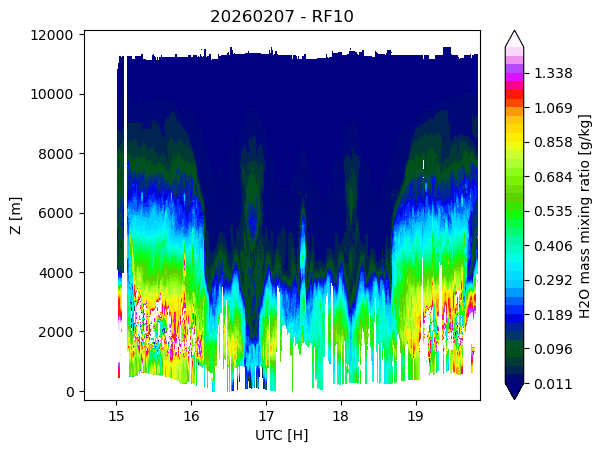

In [23]:
plt.figure()
#lvls = np.arange(0.05,5,0.1)
cs = plt.contourf(time/3600.0,z,halo['DataProducts']['h2o_mmr_v'][:].T,levels=lvls,extend='both',cmap=plt.cm.gist_ncar)
plt.xlabel('UTC [H]')
plt.ylabel('Z [m]')
plt.title(daystr+' - '+rf)
plt.colorbar(cs,label='H2O mass mixing ratio [g/kg]')
plt.show()

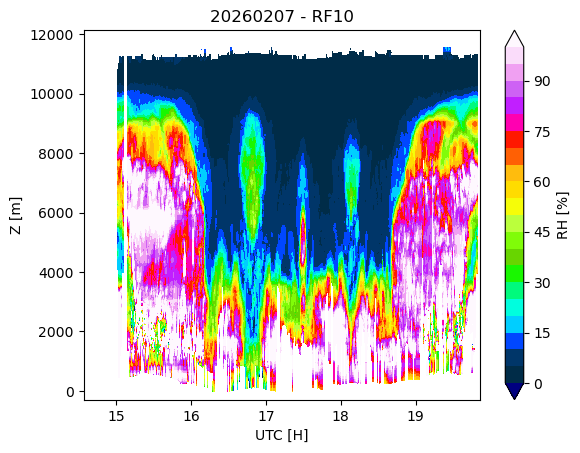

In [24]:
plt.figure()
rhlvls = np.arange(0.0,101,5)
cs = plt.contourf(time/3600.0,z,halo['DataProducts']['RHw_v'][:].T,levels=rhlvls,extend='both',cmap=plt.cm.gist_ncar)
plt.xlabel('UTC [H]')
plt.ylabel('Z [m]')
plt.title(daystr+' - '+rf)
plt.colorbar(cs,label='RH [%]')
plt.show()

# Plot the drop sondes

In [25]:
s.dtype.names

('Time_Start',
 'ElaspedTime',
 'Pressure',
 'Temperature',
 'RH',
 'WindSpeed',
 'WindDir',
 'Latitude',
 'Longitude',
 'Pressure_Altitude',
 'GPS_Altitude',
 'Dewpoint',
 'U_wind',
 'V_wind',
 'W_wind',
 'DescentRate',
 'MixingRatio',
 'Theta',
 'Theta_e',
 'Theta_v',
 'T_virtual')

In [26]:
s['Time_Start']/3600.0

array([19.11986111, 19.11993056, 19.12      , ..., 19.31651944,
       19.31658889, 19.31749167])

In [27]:
title = [l for l in s_dict if 'Launch Time' in l][0]

In [28]:
def line_and_val(ax,alt,v,i,unit):
    ax.axhline(alt[i])
    ax.text(v[i],alt[i],'{:3.3f} [{}]'.format(v[i],unit))

In [29]:
np.nanargmin(s['Temperature'])

528

In [30]:
def plot_sonde_data(s,s_dict):
    fig,ax = plt.subplots(1,7,figsize=(14,5),sharey=True)
    itrop = np.nanargmin(s['Temperature'])
    ax[0].plot(s['Latitude'],s['GPS_Altitude'],color='tab:blue',marker='.',ls='-',label='Latitude')
    ax[1].plot(s['Longitude'],s['GPS_Altitude'],color='tab:blue',marker='.',ls='-',label='Longitude')
    ax[0].set_ylabel('GPS Altitude [m]')
    ax[0].set_xlabel('Latitude [°]')
    ax[1].set_xlabel('Longitude [°]')
    
    ax[2].plot(s['Temperature'],s['GPS_Altitude'],color='tab:orange',marker='.',ls='-',label='Temperature')
    ax[3].plot(s['MixingRatio'],s['GPS_Altitude'],color='tab:orange',marker='.',ls='-',label='Mixing Ratio')
    ax[2].set_xlabel('Temperature [K]')
    ax[3].set_xlabel('Mixing Ratio [g/kg]')
    ax[4].plot(s['RH'],s['GPS_Altitude'],color='tab:red',marker='.',ls='-',label='RH')
    ax[4].set_xlabel('RH [%]')
    
    ax[5].plot(np.nancumsum(s['MixingRatio']),s['GPS_Altitude'],color='tab:red',marker='.',ls='-',label='Mixing Ratio')
    ax[5].set_xlabel('Cumulative Mixing Ratio [g/kg]')
    
    line_and_val(ax[0],s['GPS_Altitude'],s['Latitude'],itrop,'°')
    line_and_val(ax[1],s['GPS_Altitude'],s['Longitude'],itrop,'°')
    line_and_val(ax[2],s['GPS_Altitude'],s['Temperature'],itrop,'K')
    line_and_val(ax[3],s['GPS_Altitude'],s['MixingRatio'],itrop,'g/kg')
    line_and_val(ax[4],s['GPS_Altitude'],s['RH'],itrop,'%')
    line_and_val(ax[5],s['GPS_Altitude'],np.nancumsum(s['MixingRatio']),itrop,'g/kg')
    
    for j,a in enumerate(ax):
        a.grid()
        if j>0:
            a.set_yticklabels([])
        
    fig.suptitle([l for l in s_dict if 'Launch Time' in l][0])
    return fig,itrop

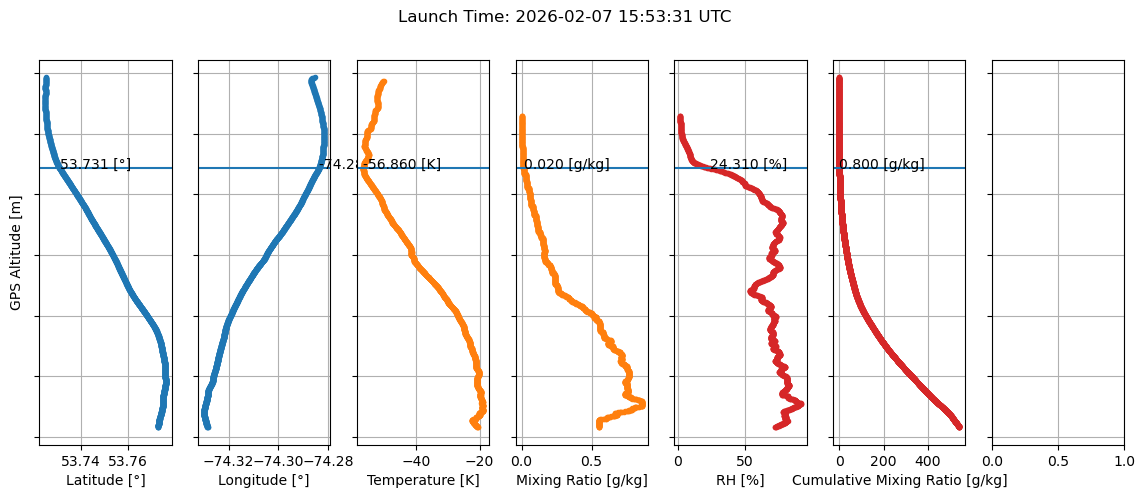

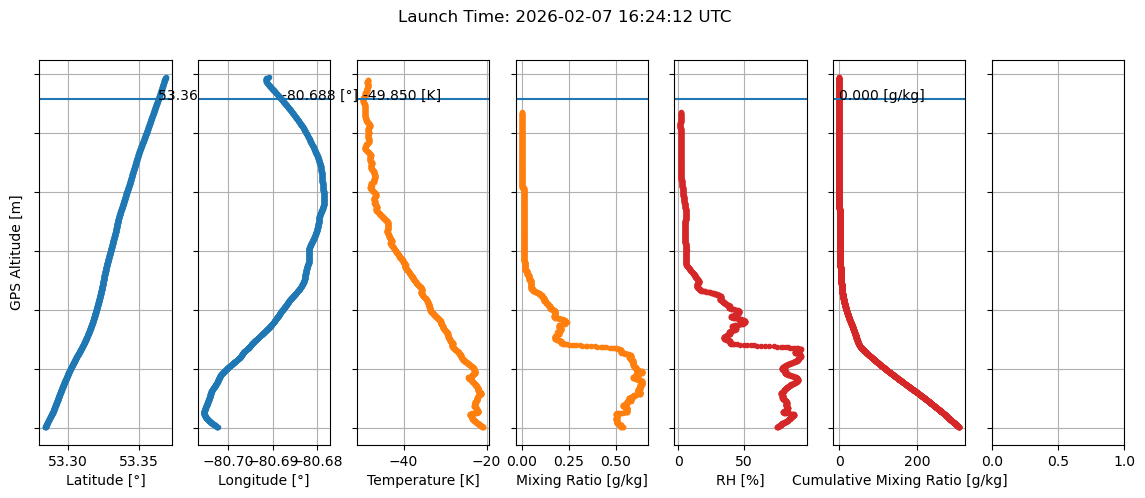

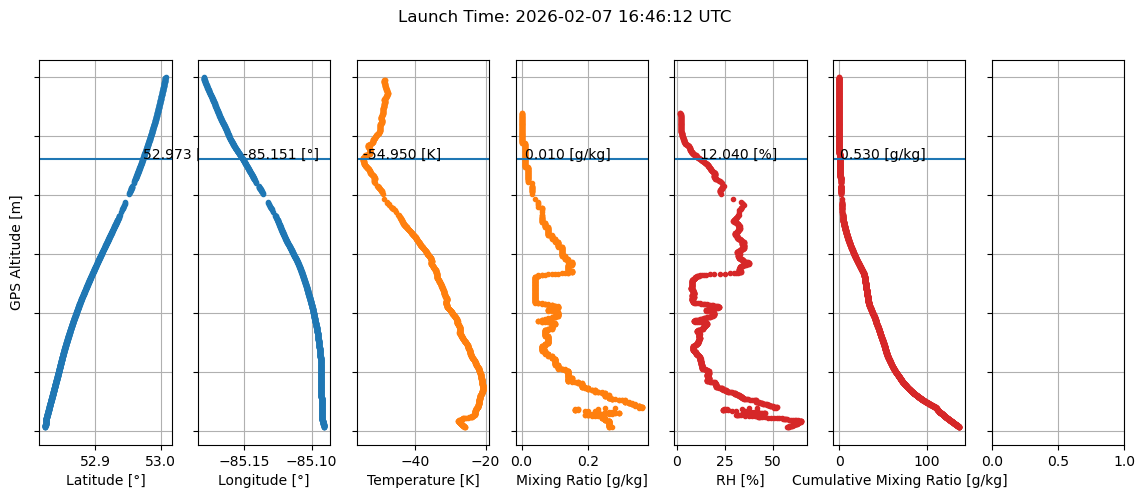

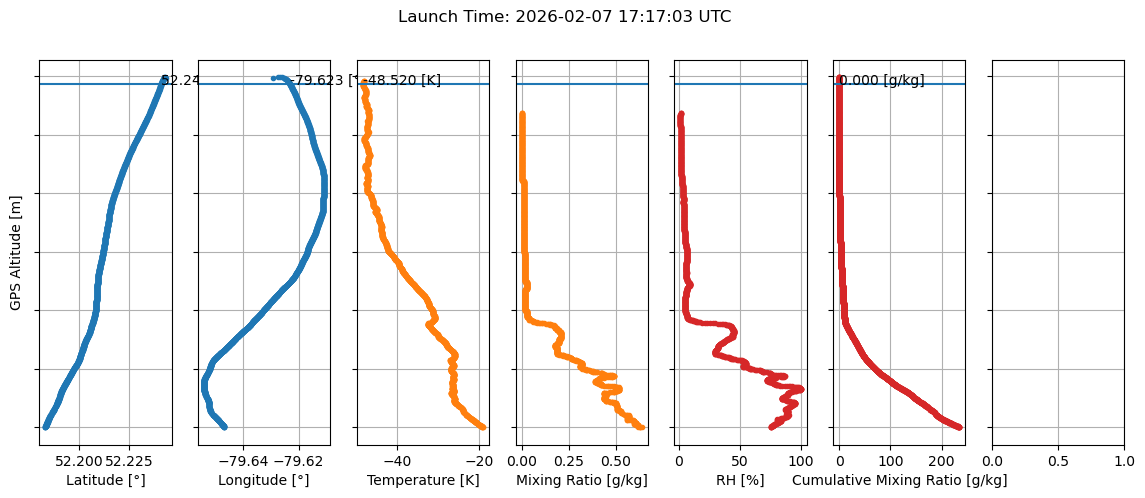

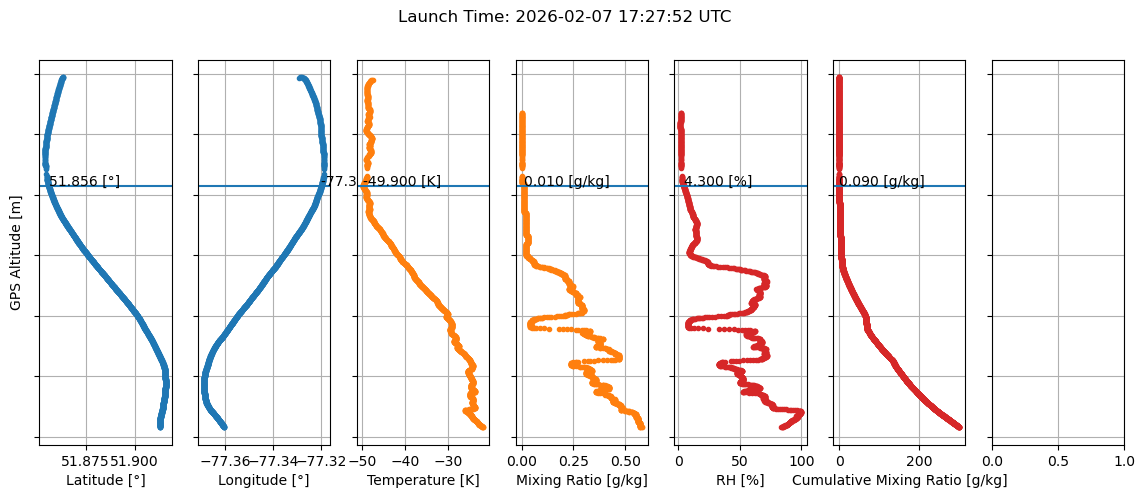

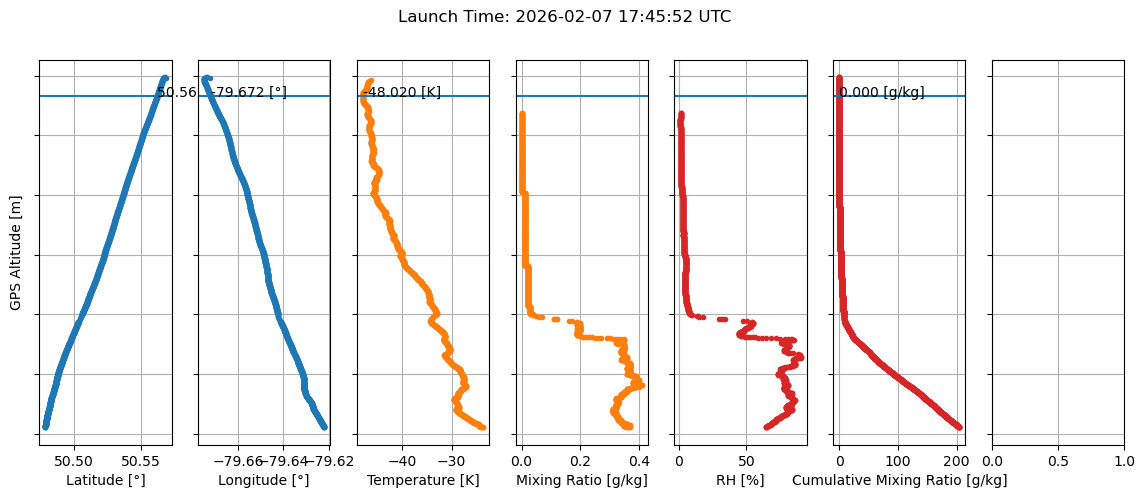

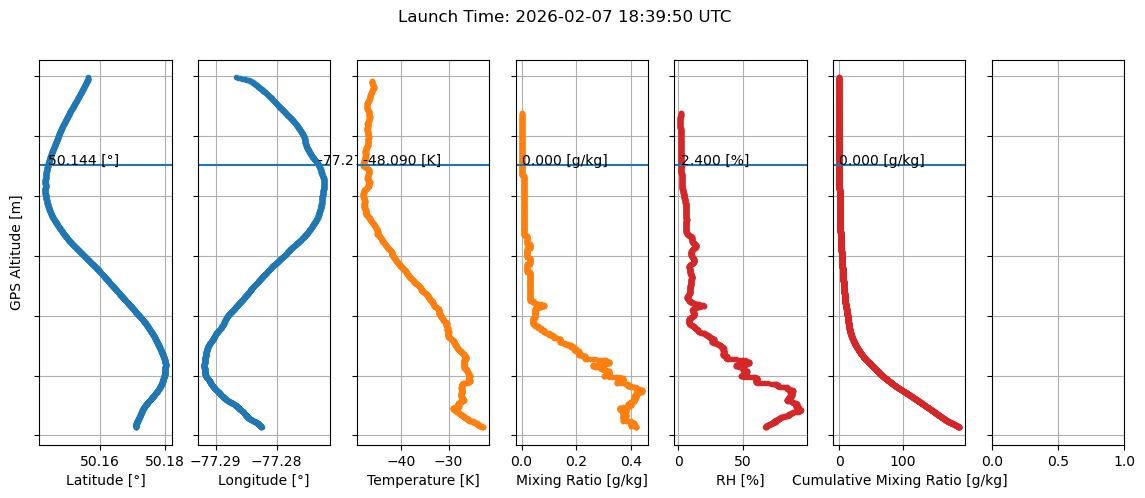

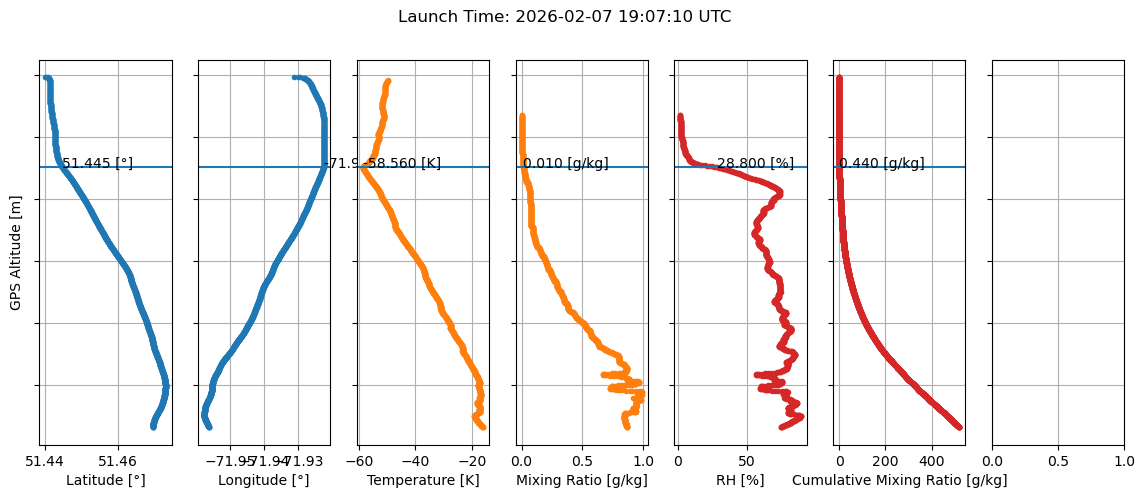

In [156]:
for jj,s in enumerate(sonde):
    plot_sonde_data(s,sonde_hdr[jj])

# a